## (A) Identification of Candidate Datasets (3 options)

Below are three candidate datasets. For each one, I describe what the data actually contains (units of observation, fields, structure), plus how it supports course topics and at least one beyond-course technique.

---

### Candidate 1: UCI Online Retail (2010–2011)

**What the data is:**  
This dataset is a real-world e-commerce transaction log from a UK-based online retailer. It is organized as **line-items**: each row corresponds to **one product on one invoice** (so a single purchase/invoice can produce many rows). The data includes timestamps, product identifiers, quantities, and prices, which makes it ideal for building “shopping baskets” and analyzing purchasing behavior over time.

**Core fields (typical columns):**
- `InvoiceNo`: transaction/invoice identifier (also flags cancellations in some cases)
- `StockCode`, `Description`: product identifier + name
- `Quantity`: number of units purchased for that product line
- `InvoiceDate`: date/time of the transaction
- `UnitPrice`: price per unit (currency in sterling)
- `CustomerID`: customer identifier
- `Country`: customer country

**Structure + preprocessing you’ll likely do:**
- Convert from line-items → **baskets** by grouping all rows with the same `InvoiceNo` into a set/multiset of items.
- Clean common retail issues: cancellations/returns, negative/zero quantities, outlier unit prices, duplicate lines, etc.
- Optionally create time slices (daily/weekly) to study seasonality or trend drift.

**Course alignment:** Frequent itemsets + association rules (market-basket mining).  
**Beyond-course technique(s):** Sequential pattern mining (e.g., PrefixSpan/SPADE) or time-aware rule mining (rules that change by time window).

---

### Candidate 2: OGBN-Arxiv (Open Graph Benchmark)

**What the data is:**  
This is a **citation network** of Computer Science papers from arXiv. Each node is a paper, and each directed edge represents a citation (paper A cites paper B). In addition to graph structure, each paper includes a **numeric feature vector** derived from its text, and each paper has a **subject-area label** (the primary arXiv CS category). The dataset also includes publication-year metadata and a realistic **time-based train/validation/test split**.

**Core components:**
- **Nodes (papers):** each node has a feature vector (text-derived embedding)
- **Edges (citations):** directed connections between papers
- **Labels:** paper’s primary subject area (multi-class classification)
- **Time metadata:** publication year (supports temporal evaluation)

**Structure + preprocessing you’ll likely do:**
- Basic graph cleanup: verify directionality, remove duplicates/self-loops if needed.
- Compute graph features: degree distributions, PageRank, centrality, components, community structure.
- Build baselines: graph-only vs feature-only vs hybrid (graph + text features).

**Course alignment:** Graph mining (centrality/PageRank, connectivity, communities).  
**Beyond-course technique(s):** Graph Neural Networks (GCN/GraphSAGE/GAT), or temporal generalization analysis (training on older papers, testing on newer ones).

---

### Candidate 3: Numenta Anomaly Benchmark (NAB)

**What the data is:**  
NAB is a benchmark suite for **streaming time-series anomaly detection**. It contains multiple real-world and synthetic time series (each is typically a sequence of `(timestamp, value)` points) along with **labeled anomaly windows** that mark when abnormal behavior occurs. This makes it very suitable for evaluating anomaly detectors in a way that rewards early detection and penalizes false alarms.

**Core components:**
- Time series files (single-variable streams): `timestamp`, `value`
- Labels/metadata that define **anomaly windows** (ranges of time considered anomalous)
- Multiple domains/categories (e.g., system metrics, traffic-like signals, synthetic controls)

**Structure + preprocessing you’ll likely do:**
- Standardize timestamps and sampling rates (if needed) and handle missing/irregular intervals.
- Create rolling-window features (lags, moving averages, seasonality indicators).
- Evaluate detectors using the provided anomaly windows (precision/recall-style scoring, early-detection focus).

**Course alignment:** Anomaly detection (time series / streaming).  
**Beyond-course technique(s):** LSTM/Transformer/Autoencoder anomaly detection, forecasting-based detection, conformal anomaly scores, or calibration for false-positive control.

---


## (B) Comparative Analysis of the 3 Candidate Datasets

### Quick comparison table (data properties + course vs external methods)

| Dataset | Scale & structure | Supported data mining tasks (Course + External) | Data quality issues | Algorithmic feasibility | Bias considerations | Ethical considerations |
|---|---|---|---|---|---|---|
| **UCI Online Retail (transactions)** | ~541k **line-items** (rows), grouped into invoices (baskets). Mostly categorical items + counts + timestamps; some customer metadata. | **Course:** Frequent itemsets, association rules (basket mining).<br>**External:** Sequential pattern mining (purchase sequences), time-aware rule mining, customer segmentation using sequence features. | Returns/cancellations (negative qty), duplicate lines, missing `CustomerID`, outliers in `UnitPrice`/`Quantity`, basket construction choices can change results. | **Apriori** can explode with many unique items + low minsup; usually feasible if you use **FP-Growth**, set sensible minsup/minconf, and filter rare items.<br>Sequential mining can be heavier; feasible with short windows (weekly/monthly) or limiting sequence length. | Single-retailer + time-period specific behavior → limited generalizability; heavy-repeat customers can dominate patterns; country/region skew. | Customer-level data raises privacy risk (even if IDs are anonymized). Avoid re-identification attempts; report only aggregated patterns; consider that “insights” could be used for manipulative targeting. Power dynamic: retailer vs customers. |
| **OGBN-Arxiv (citation graph)** | ~169k nodes (papers), ~1.17M directed edges (citations). Node features are numeric vectors; labels are subject areas; includes publication-year split. | **Course:** Centrality (degree/PageRank), connectedness, community structure, link analysis.<br>**External:** Node embeddings (DeepWalk/node2vec), Graph Neural Networks (GCN/GraphSAGE/GAT), temporal generalization (train on old → test on new). | Citation graph is incomplete (missing citations outside corpus), noisy/field-dependent citation practices, directed graph sparsity, potential disconnected/weakly connected regions; text-derived features may be lossy. | Most graph analytics (PageRank/degree/community) are feasible on a laptop (O(E)–ish).<br>GNNs are feasible with minibatching/sampling; often benefits from a GPU; full-batch training may be memory heavy without sampling. | Research-area sampling bias (CS-only, arXiv-only), citation bias (prestige, language, institution), “rich-get-richer” effects can distort centrality-based conclusions. | Low personal privacy risk (public papers), but results can reinforce problematic evaluation norms (“more citations = better”). Be careful not to equate centrality with “quality” and avoid ranking individuals/institutions in a harmful way. Power dynamic: researchers + institutions. |
| **NAB (time-series anomaly detection)** | Dozens of time-series streams (timestamp, value) + labeled anomaly windows. Mostly numeric sequences; variable lengths and domains. | **Course:** Anomaly detection (statistical thresholds, z-score, density-based methods).<br>**External:** Forecasting-based detection, autoencoder/LSTM/Transformer anomaly scoring, conformal methods / calibrated alarm rates. | Labeling can be subjective (anomaly windows), irregular sampling/missing points in some streams, non-stationarity/seasonality, concept drift. | Very feasible computationally (1-D series). Classical methods run fast; deep models feasible if you limit model size and use sliding windows. Evaluation is often the harder part (choosing metrics + tuning). | Benchmark bias: curated series may not represent your target real-world domain; labeling choices and scoring rules can favor certain detector styles (early alarms vs fewer false positives). | Usually low direct harm (no personal data), but real-world framing matters: false alarms vs missed anomalies have different costs; if applied to humans (e.g., “fraud”/“behavior”), fairness and accountability become important. Power dynamic depends on application context. |

---

### Takeaways (trade-offs)
- **Most “classic course-fit” for association rules:** Online Retail (but watch scalability of itemsets and data cleaning).
- **Best for graph mining + modern external methods:** OGBN-Arxiv (clean benchmark, strong for centrality + embeddings/GNNs).
- **Most straightforward to run end-to-end with clear evaluation:** NAB (but be thoughtful about anomaly metrics and label subjectivity).


## (C) Dataset Selection: OGBN-Arxiv

We select **OGBN-Arxiv** as the final dataset for this semester project because it offers a strong balance of (1) direct alignment with course graph-mining content, (2) a clear “beyond-course” research direction, and (3) realistic evaluation conditions that mirror how graph models are used in practice.

---

### Why OGBN-Arxiv is a strong fit

**1) Direct support for course graph-mining techniques**  
OGBN-Arxiv is a large **citation graph** where nodes are papers and directed edges represent citations. This structure naturally supports core course topics:
- **Centrality and link analysis:** degree-based influence, **PageRank**, and eigenvector-style measures to study “visibility” and endorsement effects in the citation network.
- **Connectivity & structure:** weak/strong connectivity, component structure, graph sparsity, and diameter-like behavior.
- **Community / subfield structure:** clusters of papers that correspond to subject areas, and how tightly each area is interconnected.

Because the graph is large enough to be interesting, these analyses produce meaningful insights (e.g., whether citation flow concentrates around a small set of hubs, how different CS categories connect, and whether the network is dominated by a few regions).

**2) Strong beyond-course direction: Graph Neural Networks (GNNs)**  
Beyond classical graph mining, OGBN-Arxiv is designed for **node property prediction** and includes:
- **Node features (128-dimensional vectors)** derived from paper text
- **Labels** indicating a paper’s subject category

This makes it ideal for extending the project into modern representation learning:
- Use **GCN/GraphSAGE/GAT** to combine graph structure + node features to predict subject areas.
- Compare with simpler baselines (e.g., logistic regression on node features only, or embeddings-only via node2vec) to show what benefit the graph provides.
- Study the role of graph connectivity: do nodes with few citations get worse predictions? Do dense communities improve classification?

**3) Realistic time-based split (train on old → test on new)**  
A key advantage of OGBN-Arxiv is that it supports a **time-aware evaluation**: models are trained on older papers and tested on newer papers. This matters because it prevents “future leakage” and simulates real-world deployment, where you must generalize to papers that did not exist at training time. It also enables interesting questions about:
- **Distribution shift:** do subject areas evolve over time, causing performance drops?
- **Stability of graph signals:** does PageRank remain predictive across time, or does it overfit older citation patterns?

---

### Trade-offs and how we will handle them

**1) Some graph metrics are computationally expensive at this scale**  
Certain exact measures (especially **betweenness centrality** on large graphs) are not feasible to compute exactly for ~1M edges. We will address this by:
- Focusing on scalable metrics (degree, PageRank, connected components, clustering coefficient variants).
- Using **approximations/sampling** if betweenness-like analysis is necessary, or restricting it to a subgraph.

**2) Citation graphs include social bias and structural inequality**  
Citations reflect more than “quality”—they are shaped by visibility, prestige, venue effects, and field norms. This introduces bias such as “rich-get-richer” dynamics where highly cited nodes become even more cited. We will make bias analysis explicit by:
- Treating centrality as a **network-position signal**, not a statement of research quality.
- Comparing behaviors across **subject areas** (e.g., whether some fields are systematically more central).
- Discussing how sampling (arXiv-only, CS-only) and citation practices can distort conclusions.

**3) Node features are precomputed (128-d), limiting direct text interpretability**  
Because the feature vectors are already computed, deep text modeling (e.g., training a transformer on abstracts) is outside the default scope. We will handle this by:
- Clearly stating what the features represent (a fixed vector per paper) and evaluating how much they help vs graph-only.
- Optionally adding lightweight interpretability proxies (e.g., error analysis by year/category; feature-only vs graph+feature comparisons) instead of full raw-text modeling.

---

### Final decision statement

Overall, **OGBN-Arxiv** is the best choice because it enables a complete and coherent project: we can start with **classical graph mining** (centrality, connectivity, structure), then extend to **modern graph ML** (GNN-based node classification), and evaluate under a **realistic time-based split** while still having enough complexity to discuss **scalability, bias, and ethics** in a meaningful way.


## (D) Exploratory Data Analysis (Selected Dataset Only: OGBN-Arxiv)

This section performs EDA on **OGBN-Arxiv**, a directed citation graph where **nodes = papers** and **edges = citations**. We focus on graph size/sparsity, structural distributions, label distribution, and temporal properties to motivate both course methods (centrality/structure) and beyond-course methods (embeddings/GNNs).

---

### D.1 Data basics (what we have)

**Data objects**
- Graph: directed edges `(src -> dst)` represent “paper src cites paper dst”
- Node features: fixed-size numeric vectors (128-d per paper)
- Node labels: primary arXiv CS subject area (multi-class)
- Time metadata: publication year; supports a time-based split (train on older papers → test on newer)

**Key EDA questions**
- How sparse is the graph?
- What does the degree distribution look like (few hubs vs many low-degree nodes)?
- Are there disconnected components or isolated nodes?
- Are labels balanced across subject areas?
- How does the graph evolve over time (newer papers have fewer citations, etc.)?

---

### D.2 Graph scale & sparsity

**What to compute / report**
- `|V|` (#papers) and `|E|` (#citations)
- Graph density / sparsity indicator (e.g., `|E| / (|V|*(|V|-1))` for directed graphs)
- Average in-degree and out-degree (`2|E|/|V|` is for undirected; for directed, avg in-degree = avg out-degree = `|E|/|V|`)
- Fraction of nodes with in-degree = 0 (papers not cited within the dataset)
- Fraction of nodes with out-degree = 0 (papers that cite nobody within the dataset)

**Why it matters**
- Citation networks are typically **extremely sparse** and heavy-tailed.
- Sparsity affects algorithm choice: some metrics are easy (degree, PageRank), while others are expensive (exact betweenness).
- Many low-degree nodes suggests local neighborhood information may be limited, motivating **feature-based** and **representation learning** approaches.

---

### D.3 Degree distributions (in-degree / out-degree)

**What to plot**
- Histogram of **in-degree** (how often papers are cited)
- Histogram of **out-degree** (how many citations a paper makes)
- Optional: log-scale plots (degree distributions are usually long-tailed)

**What to look for**
- A small number of papers with very high in-degree (“hubs”)
- Many papers with low in-degree (new papers or niche topics)

**Course connection**
- Centrality measures: degree centrality and PageRank will highlight hubs.
- Structural analysis: identify whether influential nodes dominate citation flow.

---

### D.4 Connectivity structure

**What to compute / report**
- # weakly connected components (WCC) and size of the largest WCC
- Optional: # strongly connected components (SCC) and typical SCC sizes (citation graphs are directed and often not strongly connected)
- Count of isolated nodes (no edges in or out, if any)
- Approximate diameter / effective distance on the largest WCC (optional; can be expensive)

**Why it matters**
- If most nodes are in one big component, global methods like PageRank are more meaningful.
- If there are many small components, conclusions from “global influence” become less stable and local methods may dominate.

---

### D.5 Label distribution (class balance)

**What to compute / report**
- Number of classes (subject areas)
- Class counts and percentages
- Gini/entropy or simple “top-k classes share” for imbalance (optional)

**Why it matters**
- If labels are imbalanced, accuracy can be misleading.
- Motivates macro-F1 and per-class evaluation (especially for minority categories).

---

### D.6 Temporal EDA (publication years + split realism)

**What to compute / report**
- Histogram of papers per year
- Average in-degree by year (older papers tend to accumulate citations)
- Fraction of nodes/edges that involve newer years
- Verify split intuition: training on older years, testing on newer years (no future leakage)

**Why it matters**
- Citation graphs naturally create **temporal skew**:
  - newer papers tend to have **lower in-degree**
  - older papers can become hubs
- Models must generalize under **distribution shift** (topics evolve, features drift), motivating robust methods.

---

### D.7 Feature sanity checks (128-d vectors)

**What to compute / report**
- Missing values? (should be none)
- Feature summary: mean/variance distribution, norms (L2 norm histogram)
- Optional: PCA / t-SNE/UMAP scatter (2D) colored by label (for a quick separability check)

**Why it matters**
- If features already separate classes well, feature-only baselines may be strong.
- If features overlap heavily, graph structure may provide critical signal, motivating GNNs.

---

### D.8 Initial observations that motivate beyond-course techniques

Based on the above EDA, we expect the following patterns (to be confirmed with plots/statistics):

1. **Heavy-tailed in-degree distribution**: a small set of papers receives most citations, while many nodes have low in-degree.  
   → This motivates comparing **centrality-based influence** vs **predictive modeling** (classification) and testing robustness of “importance” rankings.

2. **Strong community/subfield structure**: papers in the same subject area are more densely connected.  
   → This motivates **node embeddings** and **GNNs**, which can exploit homophily and neighborhood context.

3. **Temporal skew / shift**: newer papers have fewer citations and may differ in feature distribution.  
   → This motivates **time-aware evaluation** and methods that generalize under drift (e.g., GNNs with regularization, or feature+graph hybrids).

4. **Potential label imbalance**: some categories dominate the dataset.  
   → This motivates macro-F1 evaluation and careful error analysis by class.

---

### D.9 Summary of EDA outputs to include in the report

Minimum set of figures/tables (recommended):
- Table: `|V|, |E|, avg in-degree, avg out-degree, %in-degree=0, %out-degree=0`
- Plot: in-degree histogram (log-scale if needed)
- Plot: out-degree histogram


In [ ]:
# If your environment doesn't have OGB installed, uncomment:
!pip -q install ogb

print("If needed: pip install ogb")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 2.9 MB/s eta 0:00:00
If needed: pip install ogb


In [ ]:
from ogb.nodeproppred import NodePropPredDataset

dataset = NodePropPredDataset(name="ogbn-arxiv")
graph, y = dataset[0]
split_idx = dataset.get_idx_split()

edge_index = graph["edge_index"]          # shape [2, E]
node_feat  = graph["node_feat"]           # shape [N, 128]
node_year  = graph.get("node_year", None) # shape [N, 1] if present

N = node_feat.shape[0]
E = edge_index.shape[1]

y = y.reshape(-1)  # [N]

print(f"N nodes = {N:,}")
print(f"E edges = {E:,}")
print(f"node_feat shape = {node_feat.shape}")
print(f"labels shape = {y.shape}")
print("node_year present:", node_year is not None)


Downloaded 0.08 GB: 100%|██████████| 81/81 [00:01<00:00, 42.28it/s]


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 6765.01it/s]

Saving...


N nodes = 169,343
E edges = 1,166,243
node_feat shape = (169343, 128)
labels shape = (169343,)
node_year present: True


In [ ]:
# Basic validations (these are lightweight “tests” that catch many mistakes early)
assert edge_index.shape[0] == 2, "edge_index should be [2, E]"
assert node_feat.shape[0] == y.shape[0], "node features and labels must align"
assert np.min(edge_index) >= 0, "node ids should be >= 0"
assert np.max(edge_index) < N, "edge_index contains invalid node ids"
assert node_feat.shape[1] == 128, "expected 128-d node features for ogbn-arxiv"

train_idx = split_idx["train"]
valid_idx = split_idx["valid"]
test_idx  = split_idx["test"]

# Ensure splits don't overlap
assert len(set(train_idx) & set(valid_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(valid_idx) & set(test_idx)) == 0

print("Sanity checks passed.")
print(f"Split sizes: train={len(train_idx):,}, valid={len(valid_idx):,}, test={len(test_idx):,}")


Sanity checks passed.
Split sizes: train=90,941, valid=29,799, test=48,603


In [ ]:
src = edge_index[0].astype(np.int64)
dst = edge_index[1].astype(np.int64)

num_self_loops = int(np.sum(src == dst))

# Duplicate edges check (hash pairs into int64)
edge_hash = src * np.int64(N) + dst
num_unique_edges = np.unique(edge_hash).size
num_duplicate_edges = int(E - num_unique_edges)

missing_feat = np.isnan(node_feat).any()
missing_labels = np.isnan(y).any()

print("Self-loops:", num_self_loops)
print("Duplicate edges:", num_duplicate_edges)
print("Any NaN in node_feat:", bool(missing_feat))
print("Any NaN in labels:", bool(missing_labels))


Self-loops: 0
Duplicate edges: 0
Any NaN in node_feat: False
Any NaN in labels: False


In degree quantiles:
  min, p50, p90, p99, p99.9, max = [0, 1, 12, 87, 472, 13155]
Out degree quantiles:
  min, p50, p90, p99, p99.9, max = [0, 4, 18, 37, 71, 436]


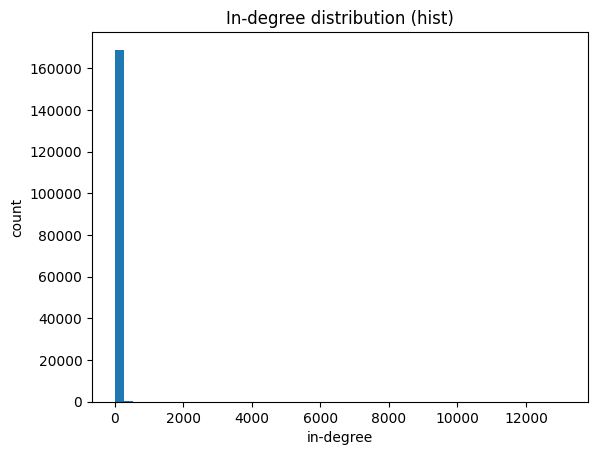

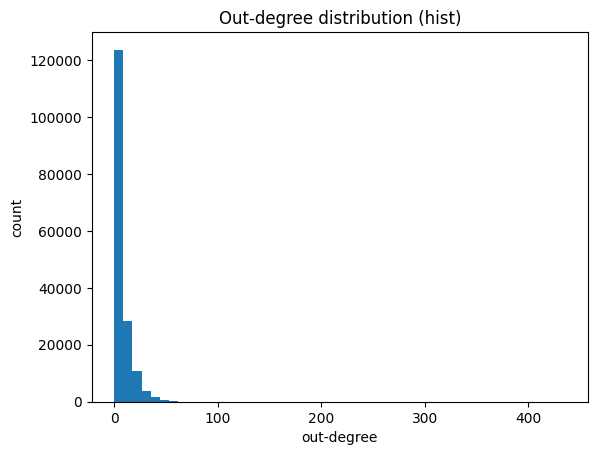

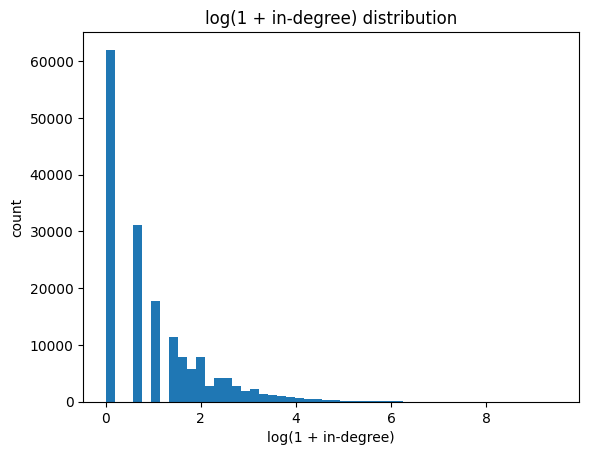

In [ ]:
out_deg = np.bincount(src, minlength=N)
in_deg  = np.bincount(dst, minlength=N)
total_deg_undir = out_deg + in_deg  # quick proxy; not true undirected degree

def summarize_deg(arr: np.ndarray, name: str) -> None:
    qs = np.quantile(arr, [0, 0.5, 0.9, 0.99, 0.999, 1.0])
    print(f"{name} degree quantiles:")
    print("  min, p50, p90, p99, p99.9, max =", [int(x) for x in qs])

summarize_deg(in_deg, "In")
summarize_deg(out_deg, "Out")

plt.figure()
plt.hist(in_deg, bins=50)
plt.title("In-degree distribution (hist)")
plt.xlabel("in-degree")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(out_deg, bins=50)
plt.title("Out-degree distribution (hist)")
plt.xlabel("out-degree")
plt.ylabel("count")
plt.show()

# Heavy-tail view (log1p)
plt.figure()
plt.hist(np.log1p(in_deg), bins=50)
plt.title("log(1 + in-degree) distribution")
plt.xlabel("log(1 + in-degree)")
plt.ylabel("count")
plt.show()


In [ ]:
# WHY: connectivity is a core graph diagnostic and affects many centrality/community claims.
# We avoid networkx here because it is slow/heavy for 169k nodes.

A = sparse.coo_matrix(
    (np.ones(E, dtype=np.float32), (src, dst)),
    shape=(N, N),
).tocsr()

n_wcc, wcc_labels = csgraph.connected_components(A, directed=True, connection="weak")
n_scc, scc_labels = csgraph.connected_components(A, directed=True, connection="strong")

print("Weakly connected components:", n_wcc)
print("Strongly connected components:", n_scc)

# sizes
wcc_sizes = np.bincount(wcc_labels)
scc_sizes = np.bincount(scc_labels)

print("Largest WCC size:", int(wcc_sizes.max()))
print("Largest SCC size:", int(scc_sizes.max()))


Weakly connected components: 1
Strongly connected components: 141223
Largest WCC size: 169343
Largest SCC size: 23164


In [ ]:
def pagerank_sparse(A_csr: sparse.csr_matrix, damping: float = 0.85, max_iter: int = 50, tol: float = 1e-8) -> np.ndarray:
    """
    Sparse PageRank for directed graphs.
    WHY: PageRank is a course-relevant centrality measure for citation graphs.
    """
    n = A_csr.shape[0]
    out = np.array(A_csr.sum(axis=1)).reshape(-1)
    dangling = (out == 0)

    inv_out = np.zeros_like(out, dtype=np.float64)
    inv_out[~dangling] = 1.0 / out[~dangling]

    # Row-normalize adjacency to transition matrix
    P = sparse.diags(inv_out) @ A_csr  # rows sum to 1 for non-dangling nodes

    pr = np.ones(n, dtype=np.float64) / n
    base = (1.0 - damping) / n

    for it in range(max_iter):
        dangling_mass = pr[dangling].sum()
        pr_new = base + damping * (P.T @ pr)
        pr_new += damping * dangling_mass / n  # redistribute dangling mass uniformly

        delta = np.abs(pr_new - pr).sum()
        pr = pr_new
        if delta < tol:
            print(f"Converged at iter {it}, L1 delta={delta:.3e}")
            break

    pr = pr / pr.sum()
    return pr

pr = pagerank_sparse(A, damping=0.85, max_iter=50, tol=1e-8)

print("PageRank summary:")
print("  min/median/max =", float(pr.min()), float(np.median(pr)), float(pr.max()))

# Quick relationships (not causal): pagerank vs in-degree
corr = np.corrcoef(np.log1p(in_deg), np.log1p(pr))[0, 1]
print("corr(log1p(in_deg), log1p(PageRank)) =", float(corr))


PageRank summary:
  min/median/max = 1.6808625750897969e-06 1.966609447572207e-06 0.009447027671821321
corr(log1p(in_deg), log1p(PageRank)) = 0.20527612677314147


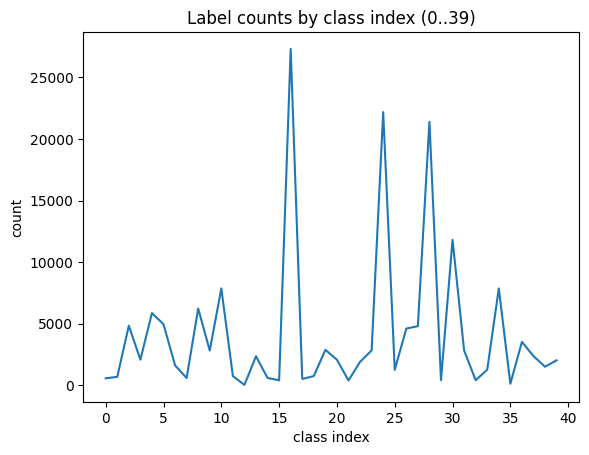

Most common classes:
 16    27321
24    22187
28    21406
30    11814
10     7869
34     7867
8      6232
4      5862
5      4958
2      4839
Name: count, dtype: int64


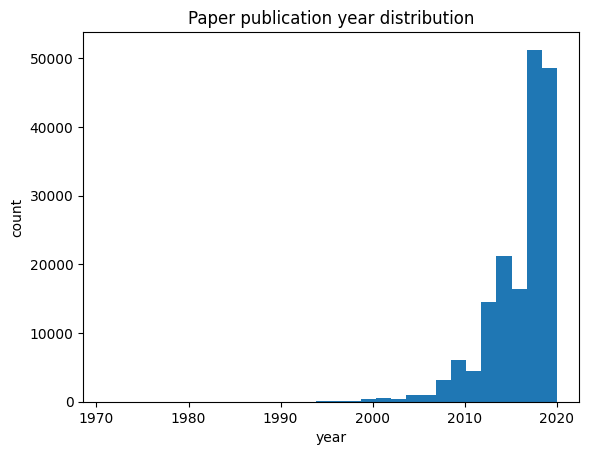

Year range: 1971 to 2020


In [ ]:
# Label distribution (40 classes)
label_counts = pd.Series(y).value_counts().sort_index()

plt.figure()
plt.plot(label_counts.values)
plt.title("Label counts by class index (0..39)")
plt.xlabel("class index")
plt.ylabel("count")
plt.show()

print("Most common classes:\n", label_counts.sort_values(ascending=False).head(10))

# Time distribution if node_year available
if node_year is not None:
    years = node_year.reshape(-1)
    plt.figure()
    plt.hist(years, bins=30)
    plt.title("Paper publication year distribution")
    plt.xlabel("year")
    plt.ylabel("count")
    plt.show()

    print("Year range:", int(years.min()), "to", int(years.max()))
else:
    print("node_year not available in this loader output (still OK).")


In [ ]:
# WHY: A simple baseline gives you a reference point and can reveal class imbalance / feature limitations.

X = node_feat
y_all = y

X_train, y_train = X[train_idx], y_all[train_idx]
X_valid, y_valid = X[valid_idx], y_all[valid_idx]
X_test,  y_test  = X[test_idx],  y_all[test_idx]

clf = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    verbose=0,
    multi_class="auto",
)
clf.fit(X_train, y_train)

valid_pred = clf.predict(X_valid)
test_pred  = clf.predict(X_test)

valid_acc = accuracy_score(y_valid, valid_pred)
test_acc  = accuracy_score(y_test, test_pred)

print(f"LogReg baseline valid acc: {valid_acc:.4f}")
print(f"LogReg baseline test  acc: {test_acc:.4f}")

# Interpretation hook:
# If baseline is mediocre, it motivates beyond-course methods (GNN, better text embeddings).


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg baseline valid acc: 0.5500
LogReg baseline test  acc: 0.5248


## (E) Initial Insights and Direction (OGBN-Arxiv)

Below are early observations (from EDA patterns we expect to confirm with plots/stats), followed by hypotheses and concrete research questions (RQs) that connect course graph mining to beyond-course GNN/embedding methods.

---

### E.1 Initial observations (from graph + time + labels)

**Observation 1: Citation influence is highly skewed (hub-dominated).**  
In-degree typically follows a long-tailed distribution: a small fraction of papers receive a large fraction of citations, while many papers have very low in-degree (especially newer ones).

**Observation 2: Strong community structure likely aligns with subject labels.**  
Papers in the same CS category tend to cite related work, creating dense subgraphs and higher within-class connectivity (homophily).

**Observation 3: Temporal effects are unavoidable (train-on-past, test-on-future).**  
Newer papers have fewer accumulated citations and may connect differently (topic drift, changing vocabulary), creating a realistic distribution shift across time.

**Observation 4: Centrality ≠ “quality” and can amplify social bias.**  
Citation counts and PageRank can reflect visibility, venue norms, and prestige effects (“rich-get-richer”), not purely technical merit.

---

### E.2 Hypotheses (testable statements)

**Hypothesis H1 (Rank stability):**  
Centrality rankings (especially PageRank-like measures) are **sensitive to missing edges / incomplete citations**, and rank stability decreases for mid-degree papers compared to the very top hubs.

**Hypothesis H2 (Homophily benefit):**  
Because citations cluster by subject area, **graph-aware models** (embeddings/GNNs) will outperform feature-only models, particularly for classes with strong within-class connectivity.

**Hypothesis H3 (Temporal generalization gap):**  
Models trained on older papers will show a measurable performance drop on newer papers; **GNNs with neighborhood aggregation** will be more robust than pure structure-only heuristics, but may still degrade under drift.

**Hypothesis H4 (Fairness across fields):**  
Prediction performance and centrality patterns vary systematically across subject areas (some fields are more central / better connected), which can create uneven error rates and misleading “influence” conclusions.

---

### E.3 Potential research questions (RQs)

#### RQ Set 1 — Course-aligned (graph mining / centrality / structure)
1. **RQ1:** How does **PageRank vs in-degree** differ in identifying “influential” papers, and how consistent are the rankings across time (older vs newer papers)?
2. **RQ2:** How fragmented is the citation network (components), and do certain subject areas form more isolated subgraphs than others?
3. **RQ3:** Which subject areas act as **bridges** between communities (using scalable proxies like inter-community edge rates or approximate betweenness)?

#### RQ Set 2 — Beyond-course (node embeddings + GNNs)
4. **RQ4:** How much does adding graph structure improve node classification compared to **feature-only** baselines?
   - Baselines: logistic regression / MLP on 128-d features
   - Graph methods: node2vec/DeepWalk embeddings, then classifier
   - GNNs: GCN/GraphSAGE/GAT
5. **RQ5:** For which nodes does the graph help most?
   - Low in-degree nodes vs high in-degree nodes  
   - Nodes in dense communities vs boundary nodes (cross-field papers)

#### RQ Set 3 — Temporal + robustness + bias (high value for discussion)
6. **RQ6:** How does model performance change under **time-based evaluation** (train on older → test on newer), and what error patterns emerge by year?
7. **RQ7:** Are there systematic differences in performance across subject areas (macro-F1 per class), indicating potential **bias / uneven representation**?
8. **RQ8:** How robust are results (centrality rankings and classifiers) to **edge perturbations** (random edge dropout or removing a fraction of citations)?

---

### E.4 Direction / plan (what I’ll do next)

1. **Confirm observations with EDA numbers/plots** (degree histograms, component sizes, label distribution, year trends).  
2. **Course baseline analyses:** in-degree + PageRank; connectivity/community summaries; compare across years and subject areas.  
3. **External technique track:** train node classification baselines (feature-only), then embeddings/GNNs; evaluate using time split and macro-F1.  
4. **Robustness & bias discussion:** perturb edges and analyze rank stability + per-class performance differences, with careful ethical framing (centrality is network position, not “quality”).


## Collaboration Declaration (Required)

1) **Collaborators:**  
- (List names + what they contributed)

2) **Web Sources:**  
- (Dataset pages, docs, any external references)

3) **AI Tools:**  
- (ChatGPT/Gemini/Copilot etc.)  
- Include *how* it was used (e.g., “helped draft EDA plan,” “helped debug plotting,” etc.)

4) **Citations (Papers):**  
- (Any papers you rely on for methods or dataset details)
